In [ ]:
# Import Pytorch
import torch
from torch import nn
# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
# Import matplotlib for visilution
import matplotlib as plt
# Check Version
print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu128
0.25.0+cu128


In [5]:
# Getting a dataset (MNIST dataset)
train_data = datasets.FashionMNIST(
    root="data",# were to download image to
    train=True, # to get train dataset
    download=True, # to download data
    transform=transforms.ToTensor(), # takes in a PIL image and returns a transformed version
    target_transform=None # to transfrom labels/target
)
test_data = datasets.FashionMNIST(root="data",
                                  train=False,
                                  download=True,
                                  transform=transforms.ToTensor(),
                                  target_transform=None)

In [6]:
len(train_data), len(test_data)

(60000, 10000)

In [7]:
# First traning example
image, label= train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [8]:
class_name = train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [11]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [12]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [13]:
print(f"Image ->{image.shape} (CC,H,W)")
print(f"Label ->{label}")

Image ->torch.Size([1, 28, 28]) (CC,H,W)
Label ->9


Image shape torch.Size([1, 28, 28])


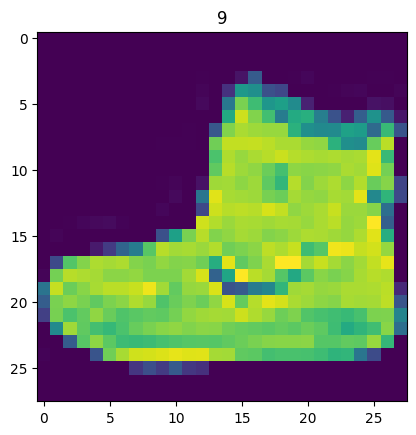

In [14]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape {image.shape}")
plt.title(label)
plt.imshow(image.squeeze())

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

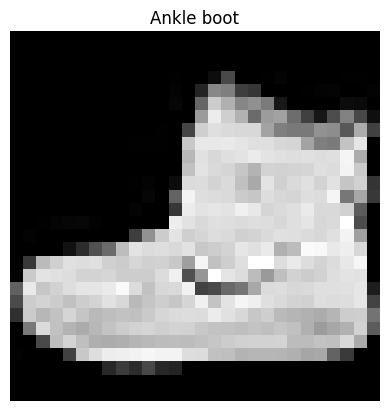

In [15]:
plt.imshow(image.squeeze(),cmap="gray")
plt.title(class_name[label])
plt.axis(False)

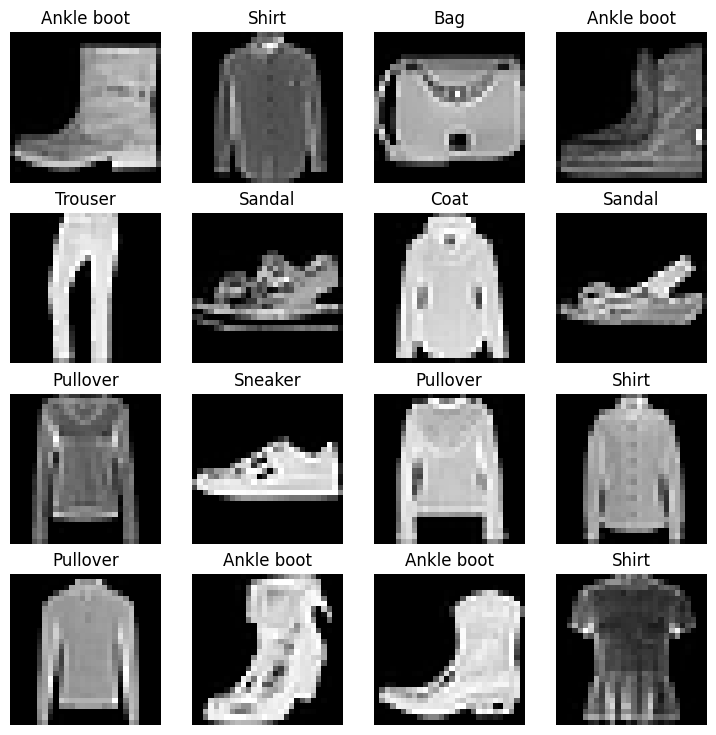

In [16]:
# torch.manual_seed(42)
fig=plt.figure(figsize=(9,9))
row,cols = 4, 4

for i in range(1 , row*cols+1):
  random_idx = torch.randint(0,len(train_data),size=[1]).item()
  img ,label = train_data[random_idx]
  plt.subplot(row,cols,i)
  plt.imshow(img.squeeze() ,cmap="gray" )
  plt.title(class_name[label])
  plt.axis(False)

In [17]:
train_data , test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [18]:
# Prepare DataLoader
from torch.utils.data import DataLoader

BATCH_SIZE=32
train_dataloader = DataLoader(batch_size=BATCH_SIZE,
                              shuffle=True,
                              dataset=train_data)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE)
test_dataloader,test_dataloader


(<torch.utils.data.dataloader.DataLoader at 0x7820e536d820>,
 <torch.utils.data.dataloader.DataLoader at 0x7820e536d820>)

In [20]:
# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7820e536d970>, <torch.utils.data.dataloader.DataLoader object at 0x7820e536d820>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [21]:
train_feature_batch , train_label_batch = next(iter(test_dataloader))
train_feature_batch.shape , train_label_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

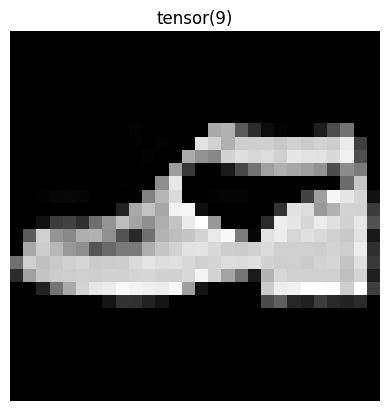

In [22]:
# Show a example
# torch.manual_seed(42)
random_idx = torch.randint(0,len(train_feature_batch),size=[1]).item()
img,lable = train_feature_batch[random_idx], train_label_batch[random_idx]
plt.imshow(img.squeeze(),cmap="gray")
plt.title(label=lable)
plt.axis(False)

In [23]:
# Model 0: Build a baseline model
flatten_model = nn.Flatten()
x=train_feature_batch[1]
output = flatten_model(x)
print(f"before flatten: {x.shape} -> [CC,H,W]")
print(f"after flatten: {output.shape} ->[CC,h*w]")


before flatten: torch.Size([1, 28, 28]) -> [CC,H,W]
after flatten: torch.Size([1, 784]) ->[CC,h*w]


In [24]:
from torch.nn.modules.linear import Linear
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self,input_unit:int, output_shape:int,hidden_unit:int):
    super().__init__()
    self.layer_stack= nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_unit, out_features=hidden_unit),
        nn.Linear(in_features=hidden_unit, out_features=output_shape)
    )
  def forward(self,x):
    return self.layer_stack(x)


In [25]:
model_0 = FashionMNISTModelV0(input_unit=784, # hight * width 28*28=784
                         hidden_unit=10,
                         output_shape=len(class_name)).to("cpu")
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [26]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[ 0.1847, -0.1432,  0.0840,  0.2599,  0.1190, -0.3267,  0.3844, -0.1385,
          0.1857,  0.3108]], grad_fn=<AddmmBackward0>)

In [27]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0091, -0.0165, -0.0042,  ..., -0.0072,  0.0142, -0.0319],
                      [ 0.0206, -0.0111, -0.0272,  ...,  0.0005,  0.0217,  0.0023],
                      [ 0.0029,  0.0097,  0.0272,  ..., -0.0184,  0.0310,  0.0307],
                      ...,
                      [ 0.0024,  0.0269, -0.0101,  ...,  0.0233, -0.0008, -0.0126],
                      [-0.0139, -0.0208, -0.0275,  ...,  0.0110,  0.0066,  0.0330],
                      [ 0.0033,  0.0030, -0.0047,  ..., -0.0257, -0.0120,  0.0228]])),
             ('layer_stack.1.bias',
              tensor([ 0.0321, -0.0169,  0.0152, -0.0084,  0.0227, -0.0054, -0.0284, -0.0354,
                      -0.0013,  0.0105])),
             ('layer_stack.2.weight',
              tensor([[-0.1864,  0.2488,  0.1500,  0.1907,  0.1457, -0.3050, -0.0580,  0.1643,
                        0.1565, -0.2877],
                      [-0.1792,  0.2305, -0.2618,  0.2397, -0.0610,  0.0232,  0.

## As Its MultiClass classification
* Loss function = CrossEntropyLoss
* Optimizer = SGD
* Evalution Matric = Accuracy

In [28]:
from urllib import request
import requests
from pathlib import Path
# Download helper function
if Path("helper_function.py").is_file():
  print("already Downloaded")
else:
  print("downloading...")
  request= requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_function.py","wb") as f:
    f.write(request.content)

already Downloaded


In [29]:
from helper_function import accuracy_fn

# Loss and optimizer
loss_fn=nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_0.parameters(),
                            lr=0.1)

In [30]:
# Function to time our experiments
from timeit import default_timer as timer
def print_train_time(start:float,
                       end:float,
                       device:torch.device=None):
  """Print dime between etart and End"""
  total_time = end-start
  print(f"total traning time on device : {device} is {total_time:.2f} sec")
  return total_time

In [31]:
start_time = timer()
#code ...
end_time=timer()
print_train_time(start=start_time,end=end_time,device = "cpu")

total traning time on device : cpu is 0.00 sec


4.558099999485421e-05

In [32]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs (we'll keep this small for faster training times)
epochs = 3

# Create training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    ### Training
    train_loss = 0
    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        # 1. Forward pass
        y_pred = model_0(X)

        # 2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulatively add up the loss per epoch

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Print out how many samples have been seen
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Divide total train loss by length of train dataloader (average loss per batch per epoch)
    train_loss /= len(train_dataloader)

    ### Testing
    # Setup variables for accumulatively adding up loss and accuracy
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # 1. Forward pass
            test_pred = model_0(X)

            # 2. Calculate loss (accumulatively)
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per epoch

            # 3. Calculate accuracy (preds need to be same as y_true)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        # Calculations on test metrics need to happen inside torch.inference_mode()
        # Divide total test loss by length of test dataloader (per batch)
        test_loss /= len(test_dataloader)

        # Divide total accuracy by length of test dataloader (per batch)
        test_acc /= len(test_dataloader)

    ## Print out what's happening
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.59528 | Test loss: 0.51095, Test acc: 81.90%

Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.47923 | Test loss: 0.48445, Test acc: 83.02%

Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.45692 | Test loss: 0.47975, Test acc: 83.41%

total traning time on device : cpu is 28.68 sec


In [33]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               ):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in tqdm(data_loader):
            # Make predictions with the model
            y_pred = model(X)

            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y,
                                y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)

        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4797506630420685,
 'model_acc': 83.40654952076677}

In [34]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [35]:
# build model_1 with non-linearity
class FashionMNISTModelV1(nn.Module):
  def __init__(self,input_shape:int, hidden_unit:int, output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape , out_features=hidden_unit),
        nn.ReLU(),
        nn.Linear(in_features=hidden_unit , out_features=output_shape),
        nn.ReLU()
    )
  def forward(self, x:torch.Tensor):
    return self.layer_stack(x)


In [36]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784,
                             hidden_unit= 10,
                             output_shape=len(class_name)).to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

In [37]:
from helper_function import accuracy_fn
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

In [38]:
# Functionizing training and test loops
def train_step(model:torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              optimizer:torch.optim.Optimizer,
              accuracy_fn,
              device:torch.device=device):

      ### Training
    model.train()
    train_loss,train_acc = 0,0
    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(data_loader):
        X,y = X.to(device),y.to(device)
        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss and accuracy (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulatively add up the loss per epoch
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()


    # Divide total train loss by length of train dataloader (average loss per batch per epoch)
    train_loss /= len(data_loader)
    train_acc /=len(data_loader)
    print(f"Train Loss: {train_loss:.2f} | Train Acc: {train_acc:.2f}% ")

In [39]:
def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )

        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [40]:
torch.manual_seed(42)
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch} \n-------------")
  train_step(model=model_1,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn)
  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn)
train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,end=train_time_end_on_gpu,device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0 
-------------
Train Loss: 1.09 | Train Acc: 61.34% 
Test loss: 0.95636 | Test accuracy: 65.00%

Epoch: 1 
-------------
Train Loss: 0.78 | Train Acc: 71.93% 
Test loss: 0.72227 | Test accuracy: 73.91%

Epoch: 2 
-------------
Train Loss: 0.67 | Train Acc: 75.94% 
Test loss: 0.68500 | Test accuracy: 75.02%

total traning time on device : cuda is 31.95 sec


In [41]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device=device):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in tqdm(data_loader):
            X,y = X.to(device), y.to(device)
            # Make predictions with the model
            y_pred = model(X)

            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y,
                                y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)

        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}



In [42]:
total_train_time_model_0

28.684672959000068

In [43]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4797506630420685,
 'model_acc': 83.40654952076677}

In [44]:
model_1_results= eval_model(model=model_1,
                            data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn,
                            device= device)
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

In [45]:
# Create a convolutional neural network
from torch import nn
class FashionMNISTModelV2(nn.Module):
    """
    Model architecture copying TinyVGG from:
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_name)).to(device)
model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [46]:
image.shape

torch.Size([1, 28, 28])

In [47]:
model_2(image.unsqueeze(0).to(device))

tensor([[ 0.0246, -0.0644,  0.0551, -0.0360, -0.0139,  0.0113, -0.0014, -0.0075,
          0.0213,  0.0076]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [48]:
# Stepping thorugh Conv2d()
torch.manual_seed(42)
# Create a bathch of image
image_test = torch.randn(32,3,64,64)
test_image = image_test[0]
print(f"Image batch Shape= ", image_test.shape)
print(f"Single image shape= ", test_image.shape)
print(f"Test Image: \n" , test_image)

Image batch Shape=  torch.Size([32, 3, 64, 64])
Single image shape=  torch.Size([3, 64, 64])
Test Image: 
 tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [

In [49]:
torch.manual_seed(42)

# Create a convolutional layer with same dimensions as TinyVGG

conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=1)

# Pass the data through the convolutional layer
conv_layer(test_image)

tensor([[[ 1.3047,  1.4238,  0.9435,  ...,  0.3078,  0.4244, -0.3909],
         [ 0.6132,  1.5396,  0.0516,  ...,  0.8711,  0.4256, -0.3416],
         [ 1.0524,  0.3662,  1.0114,  ...,  0.2809, -0.2741,  0.3787],
         ...,
         [ 0.0377,  0.2981, -0.2432,  ..., -0.7283, -0.5767, -0.0783],
         [-0.2693, -0.0386, -0.0781,  ...,  0.4228, -0.1802, -0.5140],
         [ 0.5006, -0.5684,  0.1166,  ...,  0.5425, -0.3335,  0.7756]],

        [[-0.1153,  0.5129, -0.7227,  ..., -0.6758,  0.4840, -0.8125],
         [ 0.2266, -0.2840, -0.0319,  ...,  1.5599, -1.2449, -0.4410],
         [-0.6666,  0.2753, -0.1262,  ...,  0.1999, -0.8856, -0.4292],
         ...,
         [-0.0647, -0.1984, -0.6386,  ..., -0.0585, -0.7833, -0.0764],
         [ 0.2940, -0.6306, -0.2052,  ...,  0.2456, -0.7134,  0.7373],
         [-0.1683, -0.8397,  0.2643,  ...,  0.2593, -0.5630,  0.1587]],

        [[ 0.4864, -0.7476, -0.6414,  ...,  0.5477, -1.2156,  0.2989],
         [-0.5791,  0.4414,  0.5100,  ...,  0

In [50]:
torch.manual_seed(42)
# Create a new conv_layer with different values
conv_layer_2 = nn.Conv2d(in_channels=3, # same number of color channels as our input image
                         out_channels=10,
                         kernel_size=(5, 5),
                         stride=2,
                         padding=0)

# Pass single image through new conv_layer_2 (this calls nn.Conv2d()'s forward() method on the input)
conv_layer_2(test_image).shape

torch.Size([10, 30, 30])

In [51]:
# Get shapes of weight and bias tensors within conv_layer_2
print(f"conv_layer_2 weight shape: \n{conv_layer_2.weight.shape} -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]")
print(f"\nconv_layer_2 bias shape: \n{conv_layer_2.bias.shape} -> [out_channels=10]")

conv_layer_2 weight shape: 
torch.Size([10, 3, 5, 5]) -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]

conv_layer_2 bias shape: 
torch.Size([10]) -> [out_channels=10]


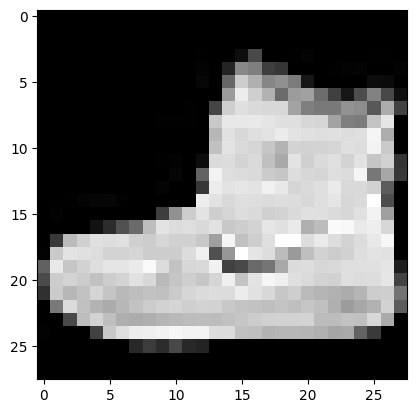

In [52]:
plt.imshow(image.squeeze(),cmap="gray")

In [53]:
# setuo loss and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_2.parameters(),
                            lr=0.1)

In [54]:
# Traning
torch.manual_seed(42)
torch.cuda.manual_seed(42)
# Mesure time
from timeit import default_timer as timer
traning_time_start_model_2 = timer()
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch} \n ----------")
  train_step(model=model_2,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             )
  test_step(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn)
traning_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=traning_time_start_model_2,end=traning_time_end_model_2 ,device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0 
 ----------
Train Loss: 0.59 | Train Acc: 78.44% 
Test loss: 0.39068 | Test accuracy: 85.84%

Epoch: 1 
 ----------
Train Loss: 0.36 | Train Acc: 87.07% 
Test loss: 0.34943 | Test accuracy: 87.17%

Epoch: 2 
 ----------
Train Loss: 0.32 | Train Acc: 88.41% 
Test loss: 0.32729 | Test accuracy: 88.34%

total traning time on device : cuda is 37.24 sec


In [55]:
model_2_result = eval_model(model=model_2,
                            data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn,
                            device= device)
model_2_result

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3272884488105774,
 'model_acc': 88.33865814696486}

In [56]:
import pandas as pd
compare_result = pd.DataFrame([model_0_results,model_1_results,model_2_result])
compare_result

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.479751,83.406550
1,FashionMNISTModelV1,0.685001,75.019968
2,FashionMNISTModelV2,0.327288,88.338658


In [57]:
# add traning time to "compare_result"
compare_result ["traning_time"]=[total_train_time_model_0,total_train_time_model_1,total_train_time_model_2]
compare_result

,model_name,model_loss,model_acc,traning_time
0,FashionMNISTModelV0,0.479751,83.406550,28.684673
1,FashionMNISTModelV1,0.685001,75.019968,31.950192
2,FashionMNISTModelV2,0.327288,88.338658,37.242467


Text(0, 0.5, 'Model')

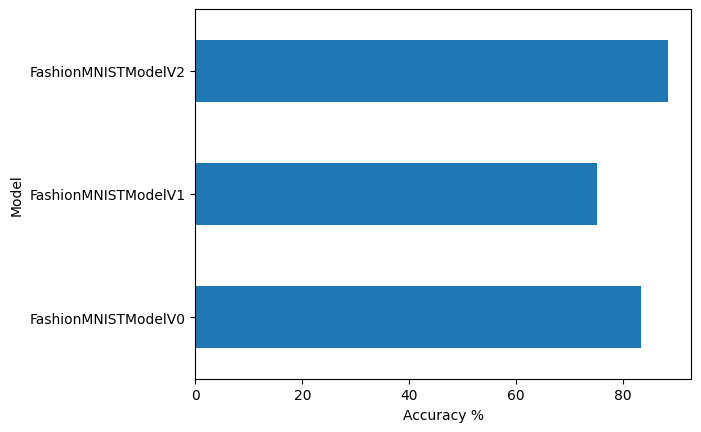

In [58]:
# visulize model
compare_result.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("Accuracy %")
plt.ylabel("Model")

Text(0, 0.5, 'Loss')

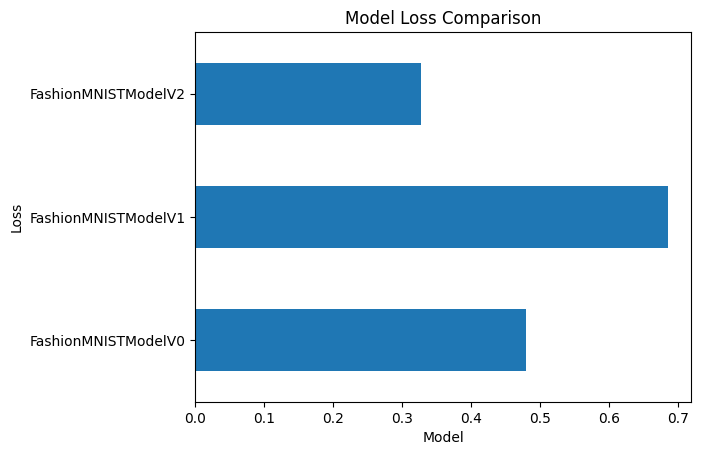

In [59]:
plt.figure()
compare_result.set_index("model_name")["model_loss"].plot(kind="barh")
plt.title("Model Loss Comparison")
plt.xlabel("Model")
plt.ylabel("Loss")

Text(0, 0.5, 'Time (seconds)')

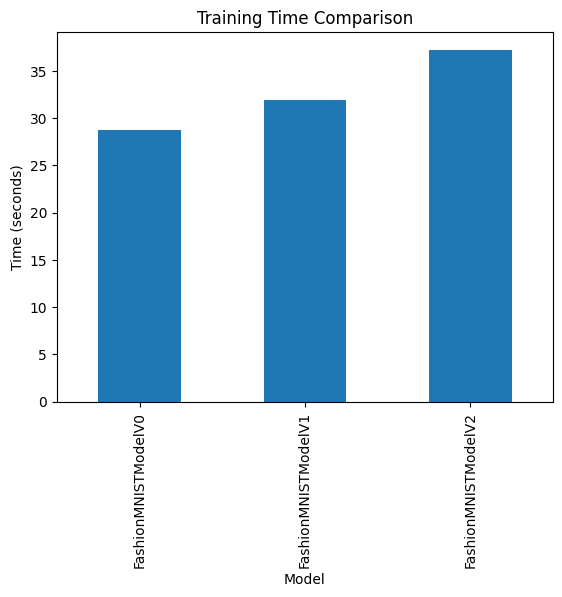

In [60]:
plt.figure()
compare_result.set_index("model_name")["traning_time"].plot(kind="bar")
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Time (seconds)")

In [61]:
def make_prediction(model:torch.nn.Module,data:list,device:torch.device=device):
  pred_probs=[]
  model.eval()
  with torch.inference_mode():
    for sample in data:
      #prepare the sample
      sample = torch.unsqueeze(sample,dim=1).to(device)
      # forward pass
      pred_logit =model(sample)
      # get pred perbability
      pred_prob=torch.softmax(pred_logit.squeeze(),dim=0)
      # get pred prob off gpu for forther calculation
      pred_probs.append(pred_prob.to("cpu"))
  # stack the pred_prob to turn list into tensor
  return torch.stack(pred_probs)


In [62]:
import random
random.seed(42)
test_sample=[]
test_label=[]
for sample , label in random.sample(list(test_data),k=9):
  test_sample.append(sample)
  test_label.append(label)
test_sample[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Sandal')

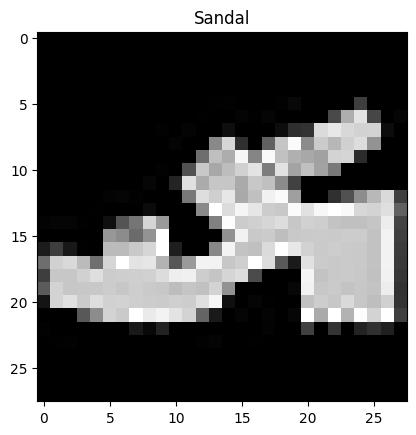

In [63]:
plt.imshow(test_sample[0].squeeze(),cmap="gray")
plt.title(class_name[test_label[0]])

In [64]:
pred_probs = make_prediction(model=model_2,
                             data=test_sample)
pred_probs[:2]

tensor([[8.0485e-07, 1.4402e-07, 1.7160e-07, 1.3531e-06, 6.2944e-08, 9.9975e-01,
         5.3213e-07, 2.1098e-05, 1.6475e-04, 5.8768e-05],
        [1.8720e-02, 7.9749e-01, 1.3895e-03, 5.6840e-02, 6.6390e-02, 1.7514e-04,
         5.8703e-02, 1.1354e-04, 5.4016e-05, 1.2379e-04]])

In [65]:
pred_classes=pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

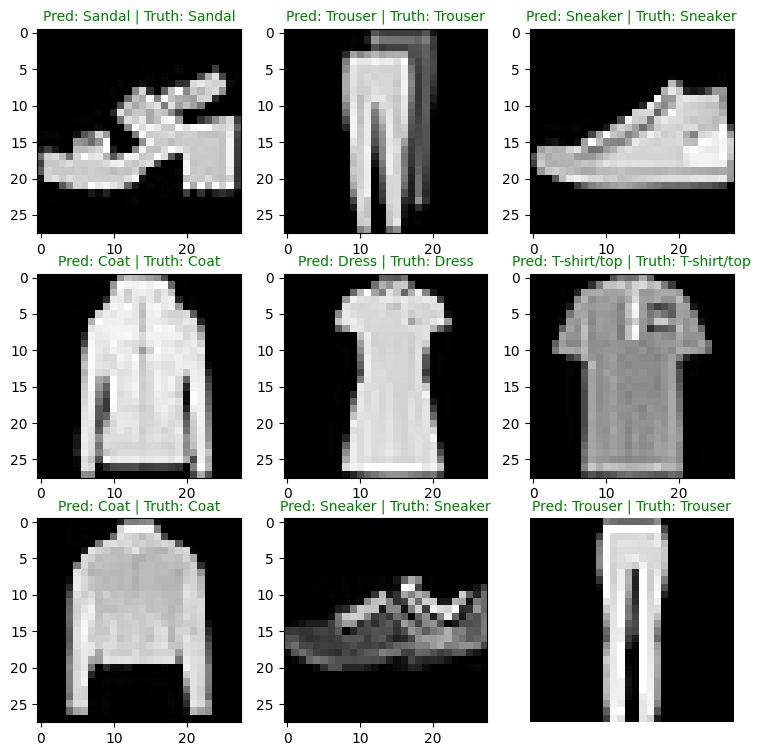

In [66]:
plt.figure(figsize=(9,9))
nrow=3
ncols=3
for i ,sample in enumerate(test_sample):
  # create Subplot
  plt.subplot(nrow,ncols,i+1)
  # plot the target image
  plt.imshow(sample.squeeze(),cmap="gray")
  # find the prediction
  pred_label=class_name[pred_classes[i]]
  # get true label
  true_label = class_name[test_label[i]]
  # title for plot
  title_text =f"Pred: {pred_label} | Truth: {true_label}"
  # Check for equality and change title colour accordingly
  if pred_label == true_label:
    plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
plt.axis(False)


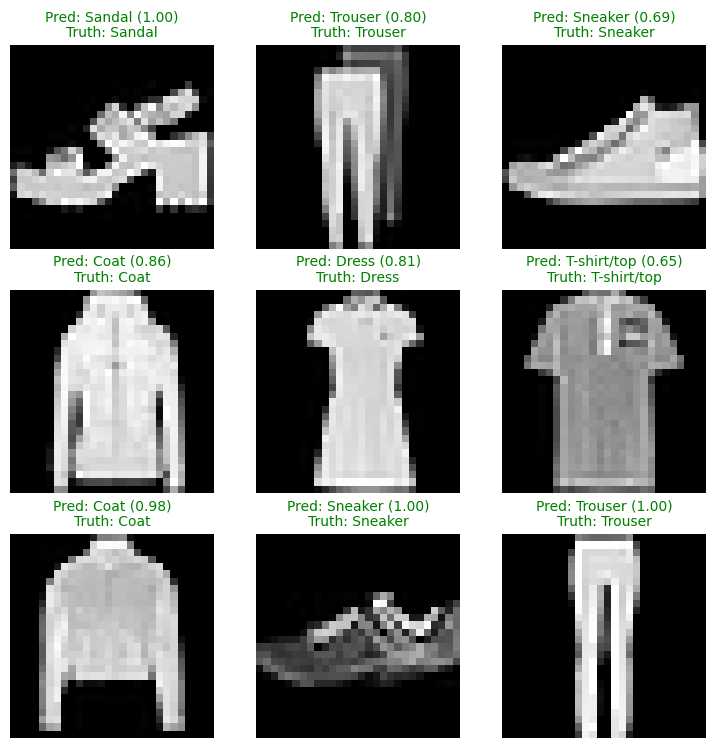

In [67]:
plt.figure(figsize=(9,9))
nrow = 3
ncols = 3

for i, sample in enumerate(test_sample):
    plt.subplot(nrow, ncols, i+1)
    plt.imshow(sample.squeeze(), cmap="gray")

    # Prediction
    pred_label = class_name[pred_classes[i]]
    true_label = class_name[test_label[i]]

    # Get confidence (max probability)
    confidence = pred_probs[i].max().item()

    # Title with probability
    title_text = f"Pred: {pred_label} ({confidence:.2f})\nTruth: {true_label}"

    # Color
    if pred_label == true_label:
        plt.title(title_text, fontsize=10, c="g")
    else:
        plt.title(title_text, fontsize=10, c="r")

    plt.axis(False)

plt.show()

In [68]:
# makeing prediction
from tqdm.auto import tqdm
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    X,y = X.to(device) , y.to(device)
    y_logit=model_2(X)
    y_pred = torch.softmax(y_logit.squeeze(),dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())

  # print(y_preds)
  y_pred_tensor = torch.cat(y_preds)
  y_pred_tensor[:5]

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

* Fix for missing packages in Google Colab
* Colab does not always have torchmetrics or mlxtend preinstalled.

In [63]:
#
#!pip uninstall -y torch torchvision torchaudio numpy
# !pip cache purge
# !pip install torch==2.10.0 torchvision==0.25.0 torchaudio==2.10.0
# !pip install numpy==1.26.4
# !pip install torchmetrics mlxtend
# import torch, torchvision, torchaudio, numpy
# import torchmetrics, mlxtend

# print(torch.__version__)
# print(numpy.__version__)

In [65]:
# !pip install torchmetrics


In [66]:
# !pip cache purge
# !pip uninstall numpy
# !pip install numpy --force-reinstall


Files removed: 42
Found existing installation: numpy 2.4.4
Uninstalling numpy-2.4.4:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/bin/numpy-config
    /usr/local/lib/python3.12/dist-packages/numpy-2.4.4.dist-info/*
    /usr/local/lib/python3.12/dist-packages/numpy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.12/dist-packages/numpy.libs/libquadmath-96973f99-934c22de.so.0.0.0
    /usr/local/lib/python3.12/dist-packages/numpy.libs/libscipy_openblas64_-32a4b2a6.so
    /usr/local/lib/python3.12/dist-packages/numpy/*
Proceed (Y/n)? y
  Successfully uninstalled numpy-2.4.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 87.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0,

In [2]:
import numpy
import torchmetrics

print(numpy.__version__)
print("torchmetrics imported successfully")

2.4.4
torchmetrics imported successfully


In [ ]:
# !pip install numpy==1.26.4 torchmetrics --upgrade

In [1]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.24.0


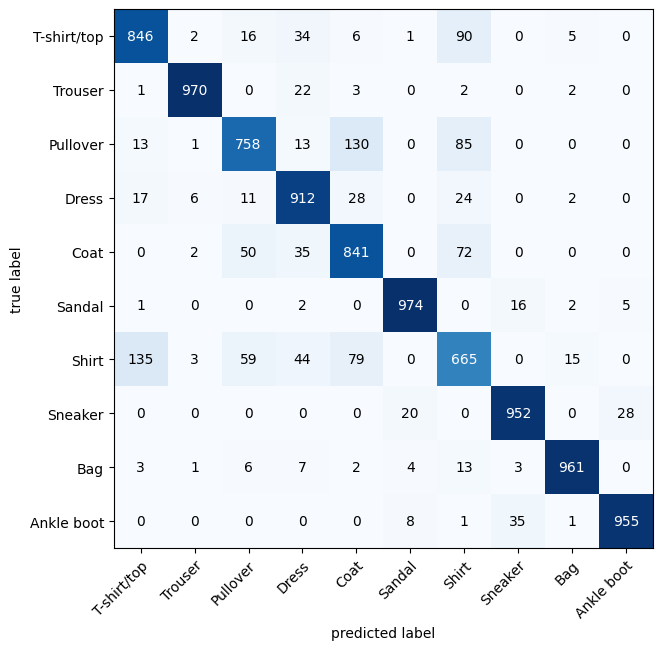

In [69]:
# Making a confusion matrix for further prediction evaluation
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_name), task="multiclass")
confmat_tensor = confmat(preds = y_pred_tensor ,
                         target = test_data.targets)
# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_name,
    figsize=(10,7)
)



In [70]:
confmat_tensor

tensor([[846,   2,  16,  34,   6,   1,  90,   0,   5,   0],
        [  1, 970,   0,  22,   3,   0,   2,   0,   2,   0],
        [ 13,   1, 758,  13, 130,   0,  85,   0,   0,   0],
        [ 17,   6,  11, 912,  28,   0,  24,   0,   2,   0],
        [  0,   2,  50,  35, 841,   0,  72,   0,   0,   0],
        [  1,   0,   0,   2,   0, 974,   0,  16,   2,   5],
        [135,   3,  59,  44,  79,   0, 665,   0,  15,   0],
        [  0,   0,   0,   0,   0,  20,   0, 952,   0,  28],
        [  3,   1,   6,   7,   2,   4,  13,   3, 961,   0],
        [  0,   0,   0,   0,   0,   8,   1,  35,   1, 955]])

In [71]:
from pathlib import Path
MODEL_PATH=Path("models")
MODEL_PATH.mkdir(parents=True,# create parent directories if needed
                 exist_ok=True  # if models directory already exists, don't error
                 )
MODEL_NAME="03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH=MODEL_PATH/MODEL_NAME
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), # only saving the state_dict() only saves the learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/03_pytorch_computer_vision_model_2.pth


In [72]:
loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                     hidden_units=10,
                                     output_shape=10)
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_2 = loaded_model_2.to(device)

In [73]:
# Evaluate loaded model
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

loaded_model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3272884488105774,
 'model_acc': 88.33865814696486}

In [74]:
model_2_result

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3272884488105774,
 'model_acc': 88.33865814696486}

In [75]:
# Check to see if results are close to each other (if they are very far away, there may be an error)
torch.isclose(torch.tensor(model_2_result["model_loss"]),
              torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-08, # absolute tolerance
              rtol=0.0001) # relative tolerance

tensor(True)